In [1]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd


In [2]:
#importing the dataset file
survey_df = pd.read_csv(r"C:\Users\Andrew\Desktop\The Frontier Institute - Programs\Data Science Program Stuff\survey_results_public.csv")

In [ ]:
#viewing the data, and unique values for the Age column
survey_df.head()
survey_df["Age"].unique()

<StringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  'Prefer not to say',  '65 years or older']
Length: 8, dtype: str

In [ ]:
print(survey_df.columns.tolist())

['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith',

In [3]:
survey_df = survey_df.drop(columns = ['JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 
                                      'JobSatPoints_10', 'JobSatPoints_11', 'TimeSearching', 'TimeAnswering', 'SurveyLength', 'SurveyEase', 'Check', 'SOVisitFreq', 'SOAccount',
                                      'SOPartFreq', 'SOHow', 'SOComm', 'NEWSOSites', 'Frequency_1', 'Frequency_2', 'Frequency_3', 'Knowledge_1' , 'Knowledge_2', 'Knowledge_3', 
                                      'Knowledge_4', 'Knowledge_5', 'Knowledge_6', 'Knowledge_7', 'Knowledge_8', 'Knowledge_9'])
survey_df.head(3)

,ResponseId,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,...,TBranch,ICorPM,WorkExp,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,...,Yes,Individual contributor,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
survey_df["DevType"].unique()

<StringArray>
[                                            nan,
                         'Developer, full-stack',
                          'Developer Experience',
                                       'Student',
                           'Academic researcher',
                               'Project manager',
                            'Developer Advocate',
                           'Developer, back-end',
                       'Other (please specify):',
                          'Developer, front-end',
                        'Database administrator',
 'Developer, desktop or enterprise applications',
                 'Cloud infrastructure engineer',
 'Data scientist or machine learning specialist',
                   'Research & Development role',
   'Developer, embedded applications or devices',
                          'System administrator',
                             'DevOps specialist',
                           'Engineering manager',
                                    

In [ ]:
survey_df['AISearchDevHaveWorkedWith'].unique()
survey_df['YearsCodePro'].unique()
print(survey_df.loc[survey_df["YearsCodePro"].isnull(), "YearsCodePro"])


0        NaN
3        NaN
4        NaN
5        NaN
7        NaN
        ... 
65427    NaN
65429    NaN
65430    NaN
65433    NaN
65436    NaN
Name: YearsCodePro, Length: 13827, dtype: str


In [4]:
#drops all rows with null values in the "YearsCodePro" column
survey_df = survey_df.dropna(subset=['YearsCodePro'])

corrected_years = [] #empty list to store corrected years

#for loop, cycles through "YearsCodePro" column, and replaces string values with rounded integers
for year in survey_df['YearsCodePro']:
   if year == "Less than 1 year":  #rounds "Less than 1 year" to 0 years
        corrected_years.append(0)
   elif year == "More than 50 years":
      corrected_years.append(51)  #rounds "More than 50 years" to 51 years
   else:
       corrected_years.append(int(year))       
survey_df['YearsCodePro'] = corrected_years

survey_df['YearsCodePro'] #test to make sure code worked

1        17
2        27
6         7
9        11
11       25
         ..
65428     7
65431    24
65432     3
65434     5
65435     2
Name: YearsCodePro, Length: 51610, dtype: int64

In [ ]:
age_numbers = []

#for loop: cycles through the dataset, and uses conditional to assign a numerical value to age ranges
#Adds the numbers in a list, into a new column, corresponding to each row
for age in survey_df['Age']:
    if age == 'Under 18 years old':
        age_numbers.append(1)      # 1 --> <18
    elif age == '18-24 years old':
        age_numbers.append(2)      # 2 --> 18-24
    elif age == '25-34 years old':
        age_numbers.append(3)      # 3 --> 25-34
    elif age == '35-44 years old':
        age_numbers.append(4)      # 4 --> 35-44
    elif age == '45-54 years old':
        age_numbers.append(5) # 5 --> 45-54
    elif age == '55-64 years old':
        age_numbers.append(6) # 6 --> 55-64
    elif age == '65 years or older':
        age_numbers.append(7) # 7 --> 65+
    else:
        age_numbers.append(-0)    # For 'prefer not to say'

# Put the list back into the dataset
survey_df['AgeCategory'] = age_numbers
survey_df.insert(3, 'AgeCategory', survey_df.pop('AgeCategory')) #Moves the column right beside 'Age', the 3rd index
survey_df.head(3)

,ResponseId,MainBranch,Age,AgeCategory,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,TBranch,ICorPM,WorkExp,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,ConvertedCompYearly,JobSat
1,2,I am a developer by profession,35-44 years old,4,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,Yes,Individual contributor,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,5,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,"I am not primarily a developer, but I write co...",35-44 years old,4,"Employed, full-time",Remote,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


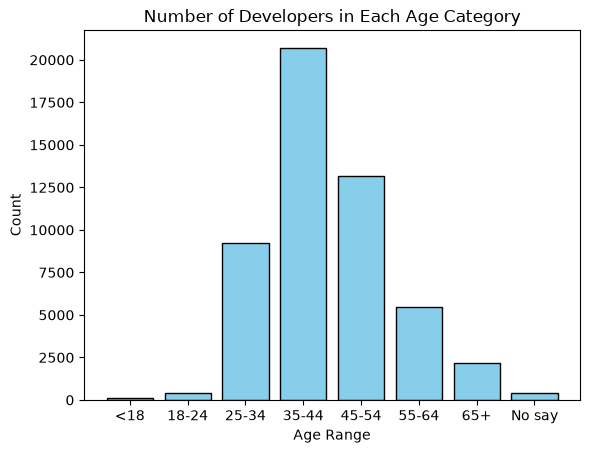

In [ ]:
#Gets counts of the age category, sorted from 0-7
age_counts = survey_df['AgeCategory'].value_counts().sort_index()

#plotting bar ,graph, with some color
plt.bar(age_counts.index, age_counts.values, color='skyblue', edgecolor='black')

#using labels to force x axis to read the age ranges, instead of 0-7
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'No say']
plt.xticks(ticks=age_counts.index[:8], labels=labels)

plt.title("Number of Developers in Each Age Category")
plt.xlabel("Age Range")
plt.ylabel("Count")
plt.show()

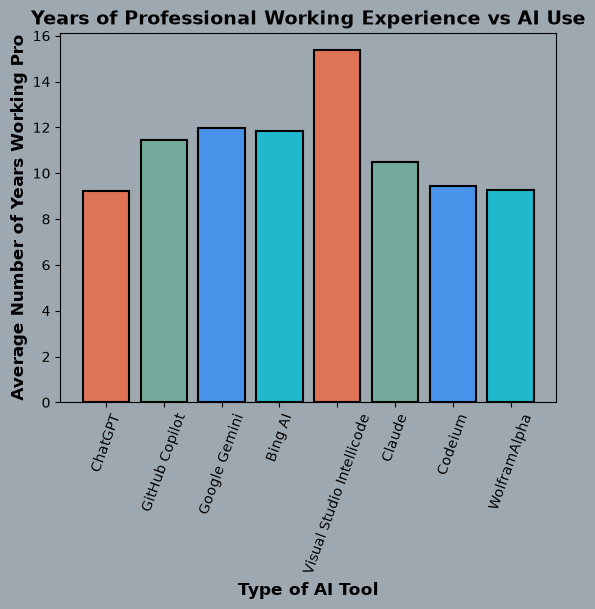

In [9]:
#Purpose of graph: shows that those who use AI tools in general have lengthy amounts of coding experience

#groups survey_df by the type of AI tool used, then gets the 'YearsCodePro" column --> gets the average per group
survey_filtered = survey_df.groupby('AISearchDevHaveWorkedWith')['YearsCodePro'].mean()

#filters to only look for a few types of AI tools in a list
averages = survey_filtered.loc[['ChatGPT', 'GitHub Copilot', 'Google Gemini', 'Bing AI',
       'Visual Studio Intellicode', 'Claude', 'Codeium', 'WolframAlpha']]

x = averages.index #names of the AI tools
y = averages.values #averages of their years coding professionally
plt.figure(facecolor='#9da8b0')
plt.bar(x, y, color=['#DE7356', '#74AA9C', '#4992ea', '#1FB8CD'], edgecolor='black', linewidth=1.5)


plt.gca().set_facecolor('#9da8b0')

plt.xticks(rotation = 70)
plt.title("Years of Professional Working Experience vs AI Use", fontsize=14, fontweight='bold')
plt.xlabel("Type of AI Tool", fontsize=12, fontweight='bold')
plt.ylabel("Average Number of Years Working Pro", fontsize=12, fontweight='bold',)
plt.show()

In [10]:
unique_values = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', 
                 '55-64 years old', '65 years or older', 'Prefer not to say']

ai_age = survey_df[["AISearchDevHaveWorkedWith", "Age"]].copy()


In [11]:
ai_age = ai_age.dropna() #drops null values

In [12]:
#Remove Prefer not to say, we don't need this input

ai_age = ai_age[
    ai_age["Age"] != "Prefer not to say"
]


In [13]:
ai_age["AISearchDevHaveWorkedWith"].head(10)

9                                ChatGPT;Google Gemini
15     ChatGPT;Google Gemini;Visual Studio Intellicode
17                                             ChatGPT
18                              ChatGPT;GitHub Copilot
20                                             ChatGPT
21                              ChatGPT;GitHub Copilot
22                                      GitHub Copilot
25                                             ChatGPT
26    ChatGPT;GitHub Copilot;Visual Studio Intellicode
27                       ChatGPT;Claude;GitHub Copilot
Name: AISearchDevHaveWorkedWith, dtype: str

In [14]:
#Splits the tools in each row
ai_age["AITool"] = (ai_age["AISearchDevHaveWorkedWith"].str.split(";"))
ai_age

,AISearchDevHaveWorkedWith,Age,AITool
9,ChatGPT;Google Gemini,35-44 years old,"[ChatGPT, Google Gemini]"
15,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,"[ChatGPT, Google Gemini, Visual Studio Intelli..."
17,ChatGPT,18-24 years old,[ChatGPT]
18,ChatGPT;GitHub Copilot,25-34 years old,"[ChatGPT, GitHub Copilot]"
20,ChatGPT,25-34 years old,[ChatGPT]
...,...,...,...
65367,ChatGPT;GitHub Copilot,25-34 years old,"[ChatGPT, GitHub Copilot]"
65388,ChatGPT;Codeium;Google Gemini,25-34 years old,"[ChatGPT, Codeium, Google Gemini]"
65399,ChatGPT,35-44 years old,[ChatGPT]
65404,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,"[ChatGPT, Claude, GitHub Copilot, WolframAlpha]"


In [15]:
#Puts each AI tool in a separate row, but they still correspond to the same people
ai_age = ai_age.explode("AITool").reset_index(drop=True)
ai_age

,AISearchDevHaveWorkedWith,Age,AITool
0,ChatGPT;Google Gemini,35-44 years old,ChatGPT
1,ChatGPT;Google Gemini,35-44 years old,Google Gemini
2,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,ChatGPT
3,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,Google Gemini
4,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,Visual Studio Intellicode
...,...,...,...
87092,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,Claude
87093,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,GitHub Copilot
87094,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,WolframAlpha
87095,ChatGPT;Google Gemini,35-44 years old,ChatGPT


In [16]:
#Remove extra spaces from tool names
ai_age["AITool"] = ai_age['AITool'].str.strip()

In [17]:
#Find the eight most commonly reported AI tools
top_tools = (ai_age["AITool"].value_counts().head(8).index)
top_tools

Index(['ChatGPT', 'GitHub Copilot', 'Google Gemini', 'Bing AI',
       'Visual Studio Intellicode', 'Claude', 'Codeium', 'Perplexity AI'],
      dtype='str', name='AITool')

In [18]:
#A new df with the only the top 8 AI tools 
ai_age_top = ai_age[ai_age["AITool"].isin(top_tools)]
ai_age_top

,AISearchDevHaveWorkedWith,Age,AITool
0,ChatGPT;Google Gemini,35-44 years old,ChatGPT
1,ChatGPT;Google Gemini,35-44 years old,Google Gemini
2,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,ChatGPT
3,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,Google Gemini
4,ChatGPT;Google Gemini;Visual Studio Intellicode,45-54 years old,Visual Studio Intellicode
...,...,...,...
87091,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,ChatGPT
87092,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,Claude
87093,ChatGPT;Claude;GitHub Copilot;WolframAlpha,35-44 years old,GitHub Copilot
87095,ChatGPT;Google Gemini,35-44 years old,ChatGPT


In [19]:
#creating a percentage table
age_percent = pd.crosstab(ai_age_top["AITool"], ai_age_top["Age"], normalize = "index") * 100
age_percent

#pd.crosstab() makes a table that compared AI tool and age group
#normalize caluclates percentrages within each AI tool

#print(ai_age_top.columns[ai_age_top.columns.duplicated()])
#print(ai_age_top.index.is_unique())

Age,18-24 years old,25-34 years old,35-44 years old,45-54 years old,55-64 years old,65 years or older,Under 18 years old
AITool,,,,,,,
Bing AI,24.780135,37.092602,21.900328,10.484566,3.448870,0.724263,1.569236
ChatGPT,20.701526,42.352066,23.635405,9.108671,2.822230,0.521027,0.859075
Claude,26.170010,38.490926,21.235275,9.391913,3.056351,0.318370,1.337154
Codeium,21.976074,40.053168,22.862206,10.722198,2.614089,0.310146,1.462118
GitHub Copilot,19.912808,41.180629,25.515494,9.573465,2.739484,0.306351,0.771769
Google Gemini,25.611927,40.264798,21.562083,8.277704,2.603471,0.411660,1.268358
Perplexity AI,24.331021,39.940535,21.605550,8.671952,2.923687,0.842418,1.684836
Visual Studio Intellicode,19.947309,34.474972,24.670681,13.643207,5.043282,0.978547,1.242002


In [20]:
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', 
                 '55-64 years old', '65 years or older']

age_percent = age_percent.reindex(index = top_tools, columns = age_order, fill_value = 0)
#index = top_tools orders tools from most commmon to least common
#columns = age order orders ages from youngest to olders
#fill values = 0  fills any missing info with 0, unnecesarry, but just leaving it there


In [21]:
age_percent = age_percent.round(2)
#rounds to 2 decimals

In [65]:
age_percent

Age,Under 18 years old,18-24 years old,25-34 years old,35-44 years old,45-54 years old,55-64 years old,65 years or older
AITool,,,,,,,
ChatGPT,4.07,23.77,38.47,21.67,8.55,2.80,0.67
GitHub Copilot,2.87,22.52,38.44,24.04,9.13,2.60,0.39
Google Gemini,5.24,29.20,35.66,19.25,7.65,2.47,0.53
Bing AI,6.74,28.33,32.29,19.00,9.57,3.23,0.84
Visual Studio Intellicode,5.42,23.15,30.86,22.39,12.52,4.69,0.97
Claude,4.42,29.65,34.50,19.15,8.87,2.96,0.45
Codeium,6.15,24.77,35.67,20.34,9.83,2.75,0.50
WolframAlpha,7.23,32.66,32.58,16.64,7.23,2.85,0.82


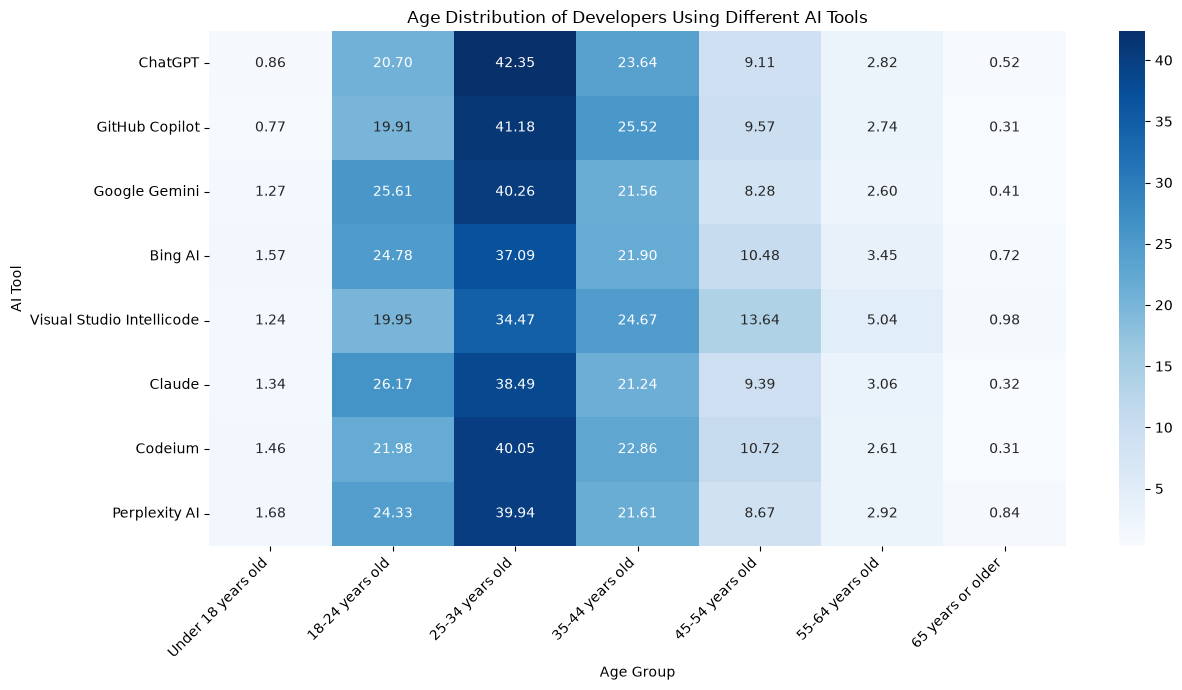

In [22]:
plt.figure(figsize = (13, 7))

sns.heatmap(age_percent, annot = True, fmt = ".2f", cmap = "Blues")

plt.title("Age Distribution of Developers Using Different AI Tools")
plt.xlabel("Age Group")
plt.ylabel("AI Tool")
plt.xticks(rotation = 45, ha = "right")

plt.tight_layout()
plt.show()

#annot = True --> displayed the percentange inside eacch cell
#fmt = ".2f" ---> displays two decimal places
#cmap = "Blues" ---> theme
#darker cells, larger percentages

In [ ]:
#Chi-squared test: Age Range to AI Tool

#Create the crosstab with raw counts (no normalize='index', no percentage)
new_crosstab = pd.crosstab(ai_age_top["AITool"], ai_age_top["Age"])

result = stats.chi2_contingency(new_crosstab)

chi2_stat = result.statistic
p_val = result.pvalue

print("Chi-Squared:", chi2_stat)
print("P-value", p_val)

#Result: < than 0.05
#DAta is significant, it's very unlikely we got this just by chance
#It's likely that age influences AI choice, strong

Chi-Squared: 659.5609263484585
P-value 6.076023870739281e-112


In [50]:
#Chi-squared test: Education Level to AI Tool
role_tool = survey_df.copy() #copy of the main dataframe
role_tool = role_tool.dropna(subset=['DevType']) #drops all 'other' specified roles

role_tool["AITool"] = (role_tool["AISearchDevHaveWorkedWith"].str.split(";")) #removes ";"
role_tool = role_tool.explode("AITool").reset_index(drop=True) #sets the Ai Tools to be individual again, new rows

role_tool["AITool"] = role_tool['AITool'].str.strip() #clears any unnecessary stuff
top_tools2 = (role_tool["AITool"].value_counts().head(8).index) #only includes the top 8 AI tools
role_tool_top_tools = role_tool[role_tool["AITool"].isin(top_tools2)] 


#Makes the crosstable
role_tool_table = pd.crosstab(role_tool_top_tools["AITool"], role_tool["DevType"])

result3 = stats.chi2_contingency(role_tool_table)

chi3_stat3 = result3.statistic
p_val3 = result3.pvalue

print("Chi-Squared:", chi3_stat3)
print("P-value", p_val3)

#Result: < than 0.05
#Data is significant, it's very unlikely we got this just by chance
#It's likely that education level influences AI tool use, not as much as age though

Chi-Squared: 1791.3344881244464
P-value 4.586243403763242e-239


In [47]:
survey_df['DevType'].value_counts()

DevType
Developer, full-stack                            17431
Developer, back-end                               9586
Developer, front-end                              3100
Developer, desktop or enterprise applications     2348
Developer, mobile                                 1887
Developer, embedded applications or devices       1560
Other (please specify):                           1553
Student                                           1539
Engineering manager                               1096
Academic researcher                               1095
Data engineer                                     1074
DevOps specialist                                  974
Data scientist or machine learning specialist      953
Research & Development role                        883
Senior Executive (C-Suite, VP, etc.)               702
Cloud infrastructure engineer                      590
Developer, game or graphics                        537
Developer, AI                                      492
De